<a href="https://colab.research.google.com/github/artyomkmm/no2-concentration-prediction/blob/main/no2_concentration_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**КИМ АРТЕМ**

# Предсказание концентрации NO₂ по данным сенсоров качества воздуха

**Датасет**:  Air Quality UCI ML Repository (ID=360)
https://archive.ics.uci.edu/dataset/360/air+quality


---
## 1. Описание проблемы

### 1.1 Зачем предсказывать качество воздуха?

Загрязнение воздуха одна из главных экологических проблем современности. NO₂ (диоксид азота) один из наиболее опасных загрязнителей

Практическая задача: построить модель, которая предсказывает концентрацию NO₂ по показаниям других сенсоров и погодным условиям в реальном времени.


---
## 2. Загрузка данных и первичный осмотр

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


import shap
import lime
import lime.lime_tabular


SEED = 42

In [ ]:
df_raw = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')

print(df_raw.columns.tolist())

df_raw = df_raw.drop(columns=['Unnamed: 15', 'Unnamed: 16'], errors='ignore')

df_raw.head()


['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16']


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [ ]:
print("Типы данных:")
print(df_raw.dtypes)

Типы данных:
Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object


---
## 3. Исследовательский анализ данных (EDA)

In [ ]:
print(f"Размер: {df_raw.shape[0]} строк, {df_raw.shape[1]} столбцов")
print(f"Дубликаты: {df_raw.duplicated().sum()}")

print("Количество значений -200 по признакам")
for col in df_raw.columns:
    count = (df_raw[col] == -200).sum()
    if count > 0:
        print(f"{col}: {count}")

print(df_raw.describe())

Размер: 9471 строк, 15 столбцов
Дубликаты: 113
Количество значений -200 по признакам
CO(GT): 1683
PT08.S1(CO): 366
NMHC(GT): 8443
C6H6(GT): 366
PT08.S2(NMHC): 366
NOx(GT): 1639
PT08.S3(NOx): 366
NO2(GT): 1642
PT08.S4(NO2): 366
PT08.S5(O3): 366
T: 366
RH: 366
AH: 366
            CO(GT)  PT08.S1(CO)     NMHC(GT)     C6H6(GT)  PT08.S2(NMHC)  \
count  9357.000000  9357.000000  9357.000000  9357.000000    9357.000000   
mean    -34.207524  1048.990061  -159.090093     1.865683     894.595276   
std      77.657170   329.832710   139.789093    41.380206     342.333252   
min    -200.000000  -200.000000  -200.000000  -200.000000    -200.000000   
25%       0.600000   921.000000  -200.000000     4.000000     711.000000   
50%       1.500000  1053.000000  -200.000000     7.900000     895.000000   
75%       2.600000  1221.000000  -200.000000    13.600000    1105.000000   
max      11.900000  2040.000000  1189.000000    63.700000    2214.000000   

           NOx(GT)  PT08.S3(NOx)      NO2(GT)  P

/tmp/ipykernel_1524/2813665087.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


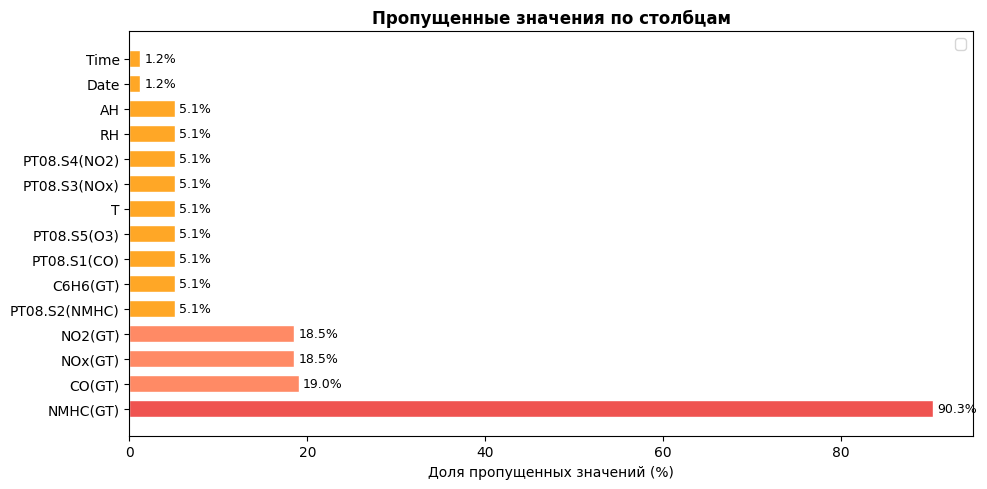

In [ ]:
df_raw = df_raw.drop_duplicates()
df = df_raw.copy()
df = df.replace(-200, np.nan)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing_data': missing, 'share': missing_pct})
missing_df = missing_df[missing_df['missing_data'] > 0].sort_values('share', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing_df.index, missing_df['share'], color=['#EF5350' if v > 50 else '#FF8A65' if v > 10 else '#FFA726'
for v in missing_df['share']], edgecolor='white', height=0.7)
ax.set_xlabel('Доля пропущенных значений (%)')
ax.set_title('Пропущенные значения по столбцам', fontweight='bold')
ax.legend()
for bar, val in zip(bars, missing_df['share']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()



Значение -200 в этом датасете специальный маркер отсутствующих данных, а не реальное измерение, поэтому мы заменили его на Nan.На графике видно, что столбец NMHC(GT) пропущен более чем на 90%  он будет исключён из анализа.

In [ ]:
df['DateTime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H.%M.%S',
    errors='coerce'
)
df = df.dropna(subset=['DateTime'])
df = df.drop(columns=['Date', 'Time', 'NMHC(GT)'])


df['Hour'] = df['DateTime'].dt.hour
df['Month'] = df['DateTime'].dt.month
df['DayOfWeek'] = df['DateTime'].dt.dayofweek
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

df = df.dropna(subset=['NO2(GT)'])

df[['DateTime','Hour','Month','CO(GT)','NO2(GT)','T','RH']].head()


,DateTime,Hour,Month,CO(GT),NO2(GT),T,RH
0,2004-03-10 18:00:00,18,3,2.6,113.0,13.6,48.9
1,2004-03-10 19:00:00,19,3,2.0,92.0,13.3,47.7
2,2004-03-10 20:00:00,20,3,2.2,114.0,11.9,54.0
3,2004-03-10 21:00:00,21,3,2.2,122.0,11.0,60.0
4,2004-03-10 22:00:00,22,3,1.6,116.0,11.2,59.6


Из столбцов Date и Time извлечены новые признаки: час суток, месяц, день недели и флаг выходного дня. Это позволяет модели учитывать суточные и недельные паттерны загрязнения. Строки без целевой переменной NO2 были удалены для более правильного обучения

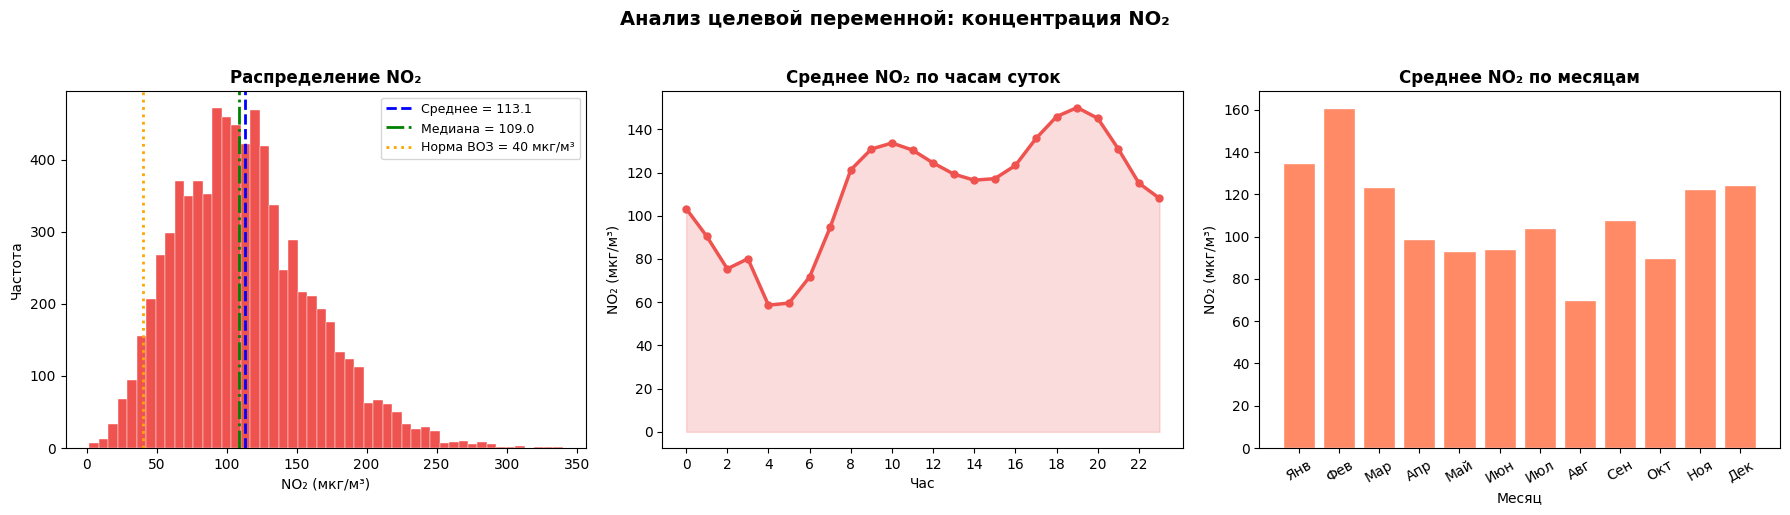

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['NO2(GT)'].dropna(), bins=50, color='#EF5350', edgecolor='white', linewidth=0.3)
axes[0].axvline(df['NO2(GT)'].mean(),   color='blue',  lw=2, linestyle='--', label=f"Среднее = {df['NO2(GT)'].mean():.1f}")
axes[0].axvline(df['NO2(GT)'].median(), color='green', lw=2, linestyle='-.', label=f"Медиана = {df['NO2(GT)'].median():.1f}")
axes[0].axvline(40, color='orange', lw=2, linestyle=':', label='Норма ВОЗ = 40 мкг/м³')
axes[0].set_title('Распределение NO₂', fontweight='bold')
axes[0].set_xlabel('NO₂ (мкг/м³)'); axes[0].set_ylabel('Частота')
axes[0].legend(fontsize=9)

hourly = df.groupby('Hour')['NO2(GT)'].mean()
axes[1].plot(hourly.index, hourly.values, color='#EF5350', lw=2.5, marker='o', markersize=5)
axes[1].fill_between(hourly.index, hourly.values, alpha=0.2, color='#EF5350')
axes[1].set_title('Среднее NO₂ по часам суток', fontweight='bold')
axes[1].set_xlabel('Час'); axes[1].set_ylabel('NO₂ (мкг/м³)')
axes[1].set_xticks(range(0, 24, 2))

monthly = df.groupby('Month')['NO2(GT)'].mean()
month_names = ['Янв','Фев','Мар','Апр','Май','Июн','Июл','Авг','Сен','Окт','Ноя','Дек']
axes[2].bar(monthly.index, monthly.values, color='#FF8A65', edgecolor='white')
axes[2].set_title('Среднее NO₂ по месяцам', fontweight='bold')
axes[2].set_xlabel('Месяц'); axes[2].set_ylabel('NO₂ (мкг/м³)')
axes[2].set_xticks(monthly.index)
axes[2].set_xticklabels([month_names[m-1] for m in monthly.index], rotation=30)

plt.suptitle('Анализ целевой переменной: концентрация NO₂', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



Распределение NO₂ смещено вправо большинство значений в диапазоне 50–200 мкг/м³, что уже превышает норму ВОЗ (40 мкг/м³). Чётко виден суточный паттерн: пики утром и вечером соответствуют часу пик на дорогах. Зимние месяцы показывают более высокие концентрации холодный воздух хуже рассеивает загрязнители.

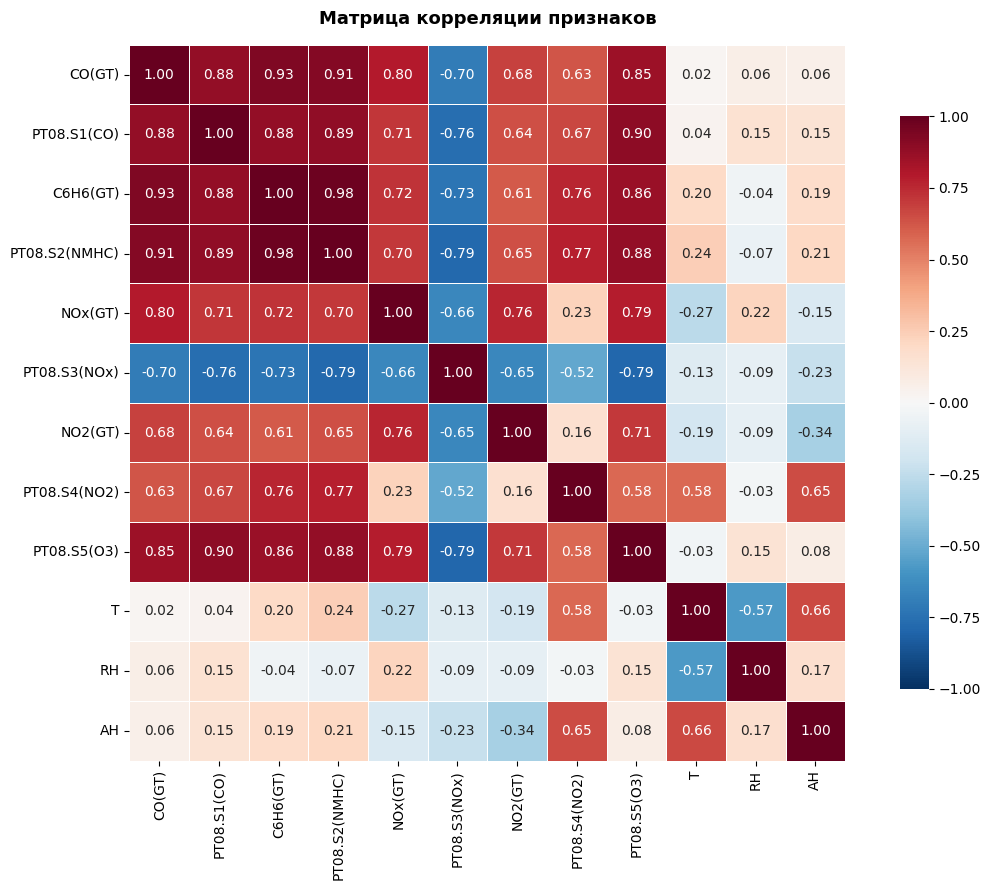

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).drop(columns=['Hour','Month','DayOfWeek','IsWeekend']).columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Матрица корреляции признаков', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


target_corr = corr['NO2(GT)'].drop('NO2(GT)').sort_values(key=abs, ascending=False)


NOx(GT) и NO2(GT) очень сильно коррелируют это логично, так как NO₂ является продуктом окисления NO.

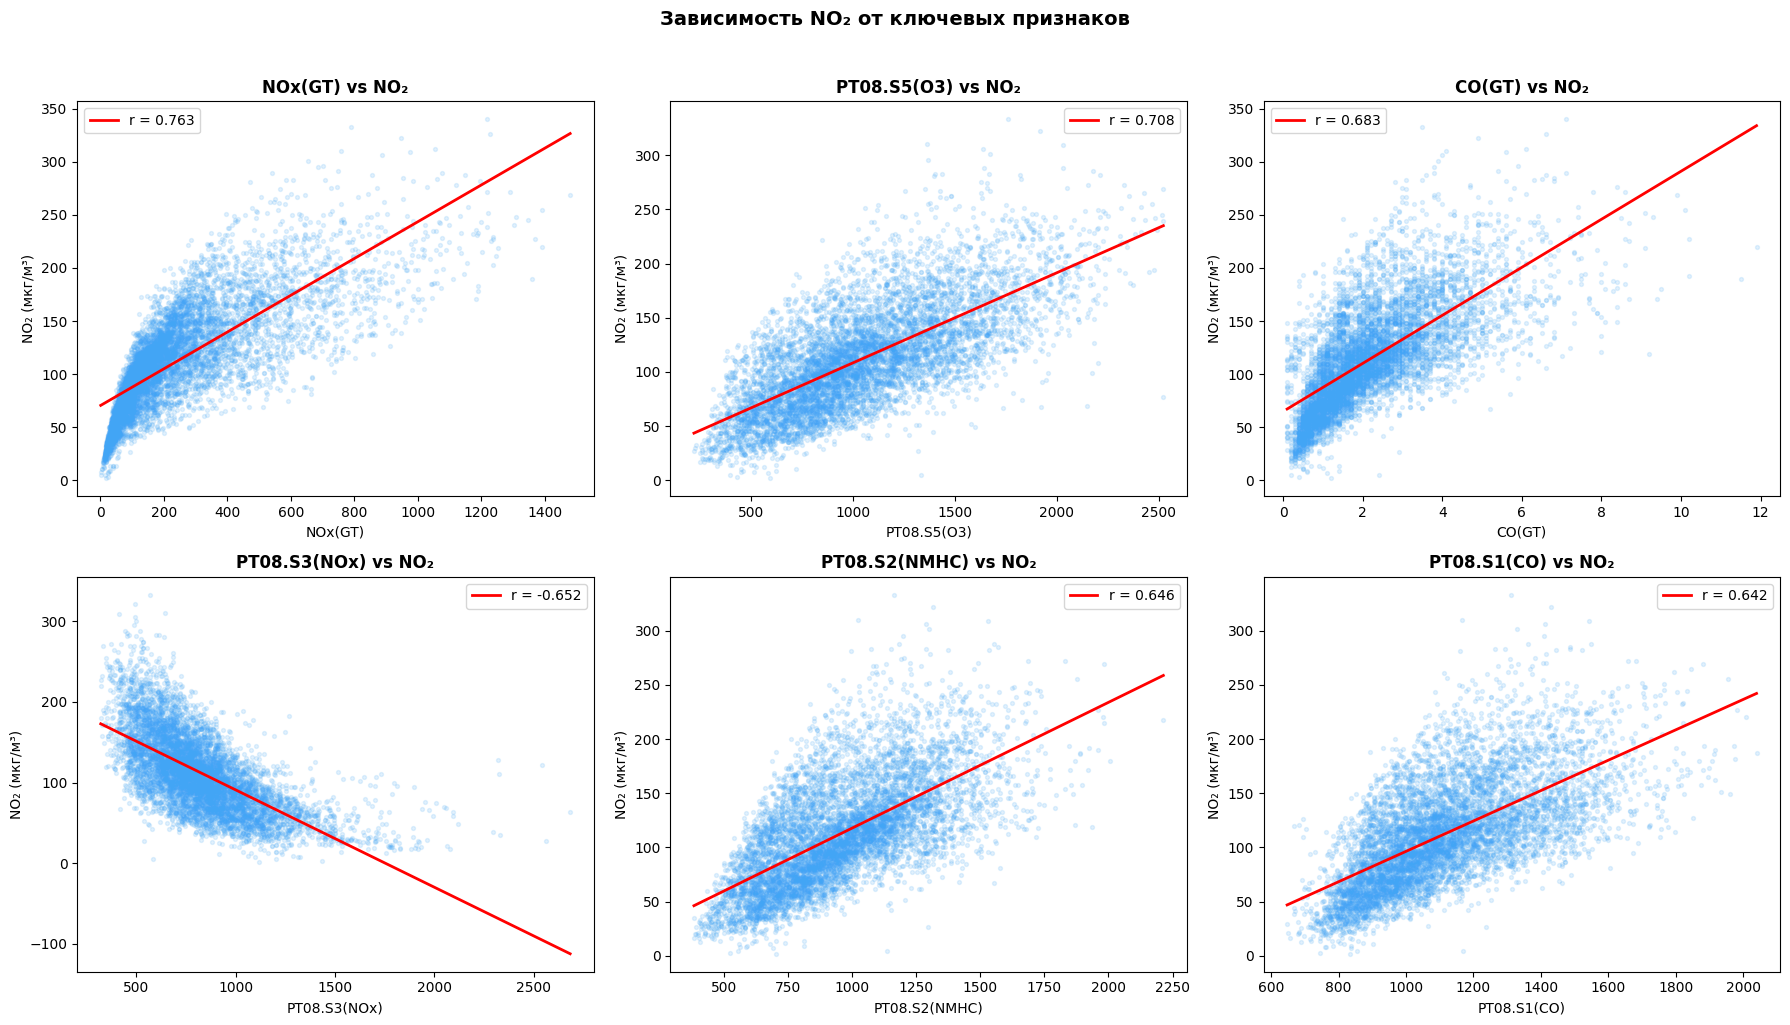

In [ ]:
top_features = target_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    data = df[[feat, 'NO2(GT)']].dropna()
    axes[i].scatter(data[feat], data['NO2(GT)'], alpha=0.15, s=8, color='#42A5F5')
    z = np.polyfit(data[feat], data['NO2(GT)'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data[feat].min(), data[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r-', lw=2, label=f'r = {data[feat].corr(data["NO2(GT)"]):.3f}')
    axes[i].set_xlabel(feat); axes[i].set_ylabel('NO₂ (мкг/м³)')
    axes[i].set_title(f'{feat} vs NO₂', fontweight='bold')
    axes[i].legend()

plt.suptitle('Зависимость NO₂ от ключевых признаков', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Зависимость между NOx и NO₂ существует, но носит нелинейный характер с высокой дисперсией . Зависимость от температуры обратная: при высокой температуре NO₂ ниже, что объясняется лучшим рассеиванием загрязнителей в тёплом воздухе.

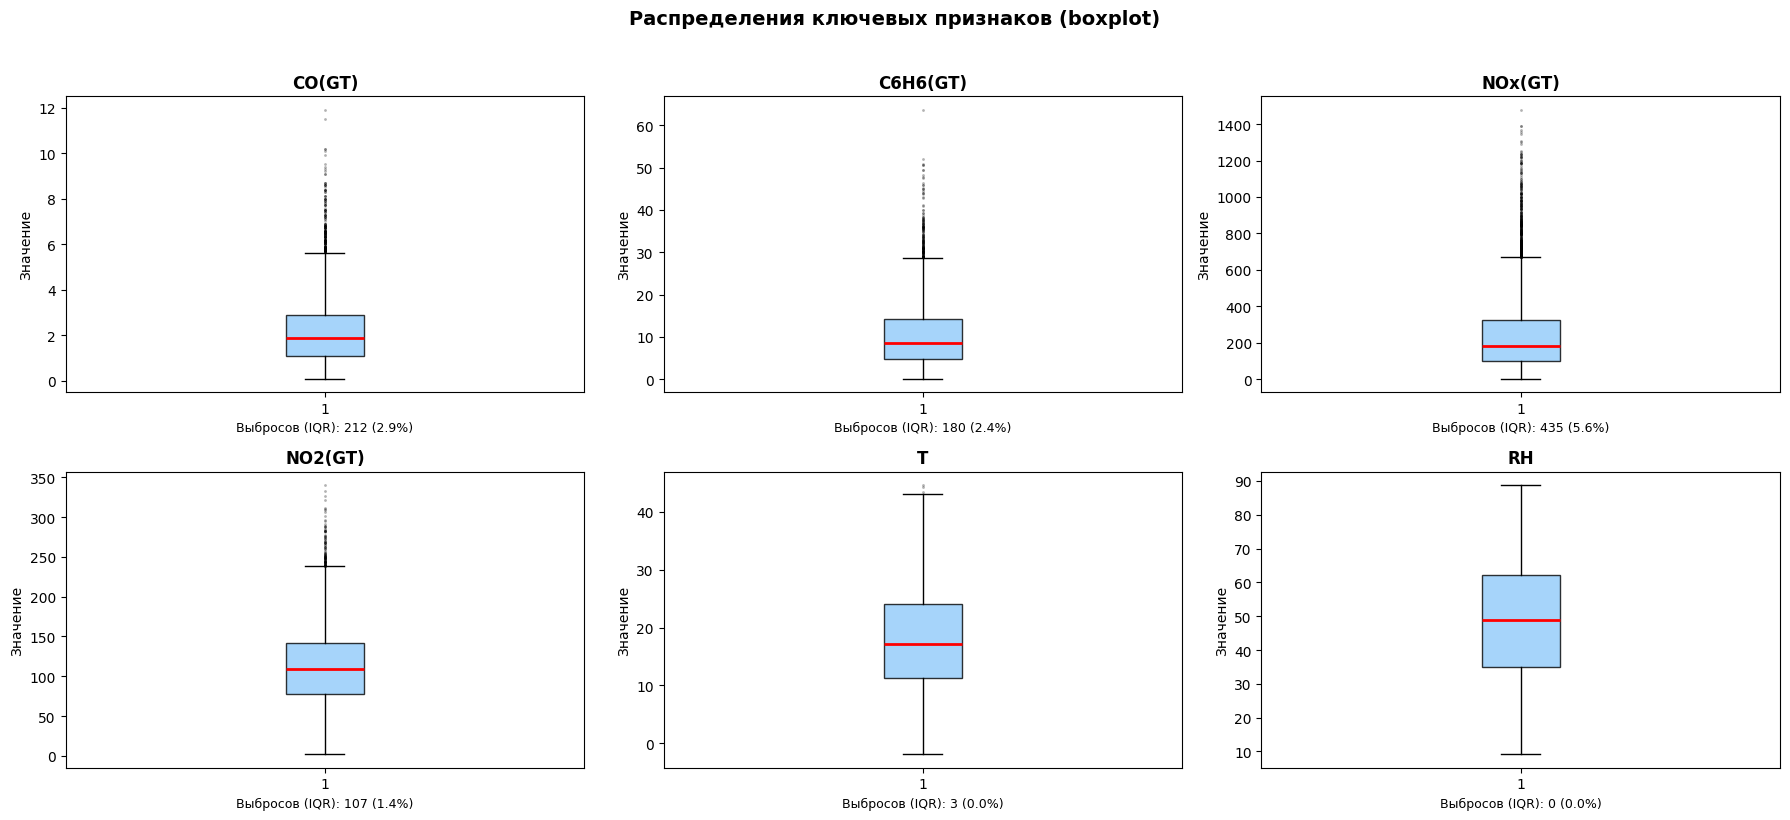

In [ ]:
sensor_cols = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)', 'T', 'RH']
sensor_cols = [c for c in sensor_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    data = df[col].dropna()
    axes[i].boxplot(data, patch_artist=True, boxprops=dict(facecolor='#90CAF9', alpha=0.8), medianprops=dict(color='red', linewidth=2),flierprops=dict(marker='.', markersize=2, alpha=0.3))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Значение')
    q1, q3 = data.quantile([0.25, 0.75])
    n_out = ((data < q1 - 1.5*(q3-q1)) | (data > q3 + 1.5*(q3-q1))).sum()
    axes[i].set_xlabel(f'Выбросов (IQR): {n_out} ({100*n_out/len(data):.1f}%)', fontsize=9)

plt.suptitle('Распределения ключевых признакецов (boxplot)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Все сенсорные переменные содержат выбросы (от 3% до 10%), что типично для реальных данных с датчиков

In [ ]:
print(f"Записей после очистки: {len(df)}")
print(f"Среднее NO₂:{df['NO2(GT)'].mean():.1f}")
print(f"Превышений нормы:{(df['NO2(GT)'] > 40).sum()} ({100*(df['NO2(GT)'] > 40).mean():.1f}%)")
print(f"Пропусков в признаках: {df.drop(columns=['DateTime','NO2(GT)']).isnull().sum().sum()}")


Записей после очистки: 7715
Среднее NO₂:113.1
Превышений нормы:7388 (95.8%)
Пропусков в признаках: 3355


После очистки осталось достаточно данных для обучения. Важно отметить, что большинство измерений превышает норму ВОЗ, что говорит о реальной экологической проблеме в исследуемом городе.

---
## 4. Предобработка данных

In [ ]:
feature_cols = [c for c in df.columns if c not in ['NO2(GT)', 'DateTime']]

X = df[feature_cols].copy()
y = df['NO2(GT)'].copy()

print("Список признаков:")
for i, col in enumerate(feature_cols, 1):
    n_missing = X[col].isnull().sum()
    print(f"{i}. {col} пропусков: {n_missing}")


Список признаков:
   1. CO(GT)               пропусков: 457
   2. PT08.S1(CO)          пропусков: 322
   3. C6H6(GT)             пропусков: 322
   4. PT08.S2(NMHC)        пропусков: 322
   5. NOx(GT)              пропусков: 0
   6. PT08.S3(NOx)         пропусков: 322
   7. PT08.S4(NO2)         пропусков: 322
   8. PT08.S5(O3)          пропусков: 322
   9. T                    пропусков: 322
  10. RH                   пропусков: 322
  11. AH                   пропусков: 322
  12. Hour                 пропусков: 0
  13. Month                пропусков: 0
  14. DayOfWeek            пропусков: 0
  15. IsWeekend            пропусков: 0


In [ ]:
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print(f"Пропусков до импутации: {X.isnull().sum().sum()}")
print(f"Пропусков после: {X_imputed.isnull().sum().sum()}")


Пропусков до импутации: 3355
Пропусков после: 0


In [ ]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_imputed),
    columns=X.columns,
    index=X.index
)

print("Статистика после масштабирования:")
print(X_scaled.iloc[:, :4].agg(['mean', 'std']).round(4))


Статистика после масштабирования:
      CO(GT)  PT08.S1(CO)  C6H6(GT)  PT08.S2(NMHC)
mean  0.0000       0.0000    0.0000        -0.0000
std   1.0001       1.0001    1.0001         1.0001


StandardScaler приводит все признаки к единому масштабу (среднее = 0, std = 1). Мы используем его спецаильно для KNN и линейнех моделей.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

---
## 5. Построение и обучение моделей

Для задачи регрессии используем те же алгоритмы что и для классификации, но в регрессионном варианте.  
Обучаем 6 моделей** на одинаковых данных.


In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'K-Nearest Neighbors': KNeighborsRegressor(n_neighbors=7),
    'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=SEED),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=SEED),
}

Выбраны 6 алгоритмов разной сложности: от простой линейной регрессии до ансамблевых методов. Такой набор позволяет оценить, насколько данные нелинейны и стоит ли усложнять модель.

In [ ]:
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

print(f"{'Модель'} {'CV RMSE'} {'±std'}")

for name, model in models.items():
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=cv_strategy,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    cv_rmse = -cv_scores.mean()
    cv_std  = cv_scores.std()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    results[name] = {
        'model': model,
        'cv_rmse': cv_rmse,
        'cv_std': cv_std,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'y_pred': y_pred,
    }
    print(f"{name} {cv_rmse} {cv_std}")


Модель CV RMSE ±std
Linear Regression 21.25468175532101 0.342209904935684
Ridge Regression 21.254147093996174 0.3448257137225048
K-Nearest Neighbors 16.776402430066486 0.5209350511084666
Decision Tree 18.491091878515395 0.6800756284156428
Random Forest 13.502473143490572 0.23733036675018745
Gradient Boosting 14.698194300641756 0.2526837194127631


 KFold с 5 фолдами даёт более честную оценку, чем одиночный split. По CV RMSE уже видно, что ансамблевые модели (RF, GBM) значительно обходят линейные, что говорит о нелинейной природе зависимостей в данных.

In [ ]:
metrics_df = pd.DataFrame({
    'CV RMSE': {k: round(v['cv_rmse'], 3) for k, v in results.items()},
    'CV': {k: round(v['cv_std'], 3) for k, v in results.items()},
    'Test MAE': {k: round(v['mae'], 3) for k, v in results.items()},
    'Test RMSE': {k: round(v['rmse'], 3) for k, v in results.items()},
    'Test R²': {k: round(v['r2'], 4) for k, v in results.items()},
}).sort_values('Test R²', ascending=False)

metrics_df


,CV RMSE,CV,Test MAE,Test RMSE,Test R²
Random Forest,13.502,0.237,9.092,13.055,0.9219
Gradient Boosting,14.698,0.253,10.307,14.220,0.9074
K-Nearest Neighbors,16.776,0.521,11.885,16.477,0.8756
Decision Tree,18.491,0.680,12.774,17.883,0.8535
Ridge Regression,21.254,0.345,15.408,20.888,0.8001
Linear Regression,21.255,0.342,15.408,20.887,0.8001


Random Forest и Gradient Boosting лидируют по всем показателям. Линейная и Ridge регрессия показывают схожие результаты Ridge не даёт заметного выигрыша, что говорит о том, что регуляризация здесь не ключевой фактор.

---
## 6. Оценка качества моделей

Метрики регрессии:
- MAE - средняя ошибка в мкг/м³.
- RMSE - штрафует за большие ошибки сильнее MAE
- R² - доля объяснённой дисперсии


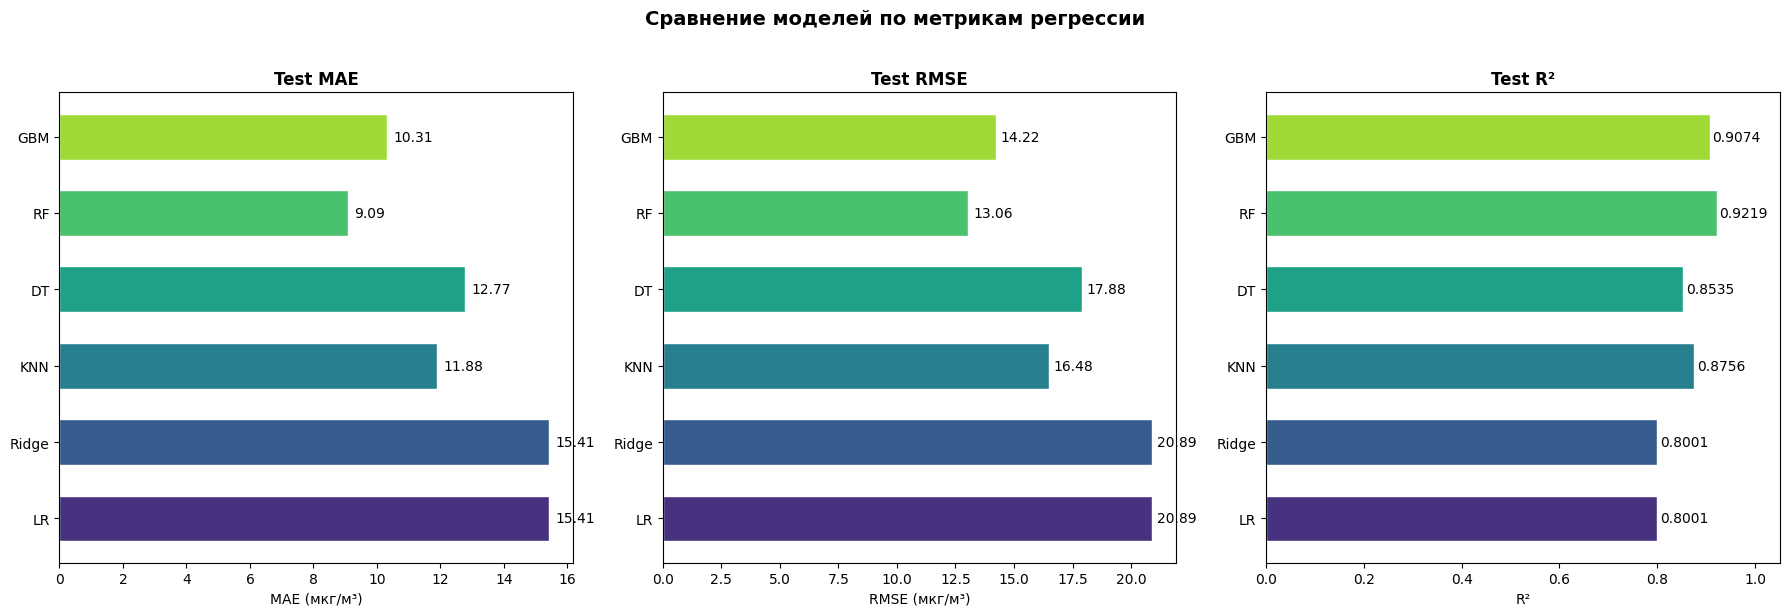

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
short = ['LR', 'Ridge', 'KNN', 'DT', 'RF', 'GBM']
palette = sns.color_palette('viridis', len(results))

vals_mae = [results[m]['mae'] for m in results]
bars = axes[0].barh(short, vals_mae, color=palette, edgecolor='white', height=0.6)
axes[0].set_title('Test MAE', fontweight='bold')
axes[0].set_xlabel('MAE (мкг/м³)')
for bar, val in zip(bars, vals_mae):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=10)

vals_rmse = [results[m]['rmse'] for m in results]
bars = axes[1].barh(short, vals_rmse, color=palette, edgecolor='white', height=0.6)
axes[1].set_title('Test RMSE', fontweight='bold')
axes[1].set_xlabel('RMSE (мкг/м³)')
for bar, val in zip(bars, vals_rmse):
    axes[1].text(val + 0.2, bar.get_y() + bar.get_height()/2,f'{val:.2f}', va='center', fontsize=10)

vals_r2 = [results[m]['r2'] for m in results]
bars = axes[2].barh(short, vals_r2, color=palette, edgecolor='white', height=0.6)
axes[2].set_title('Test R²', fontweight='bold')
axes[2].set_xlabel('R²')
axes[2].set_xlim(0, 1.05)
for bar, val in zip(bars, vals_r2):
    axes[2].text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10)

plt.suptitle('Сравнение моделей по метрикам регрессии', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Визуально подтверждается превосходство ансамблей. Разрыв между линейными моделями и Random Forest по R² существенный, что означает, что в данных есть нелинейные зависимости, которые линейные модели просто не способны уловить.

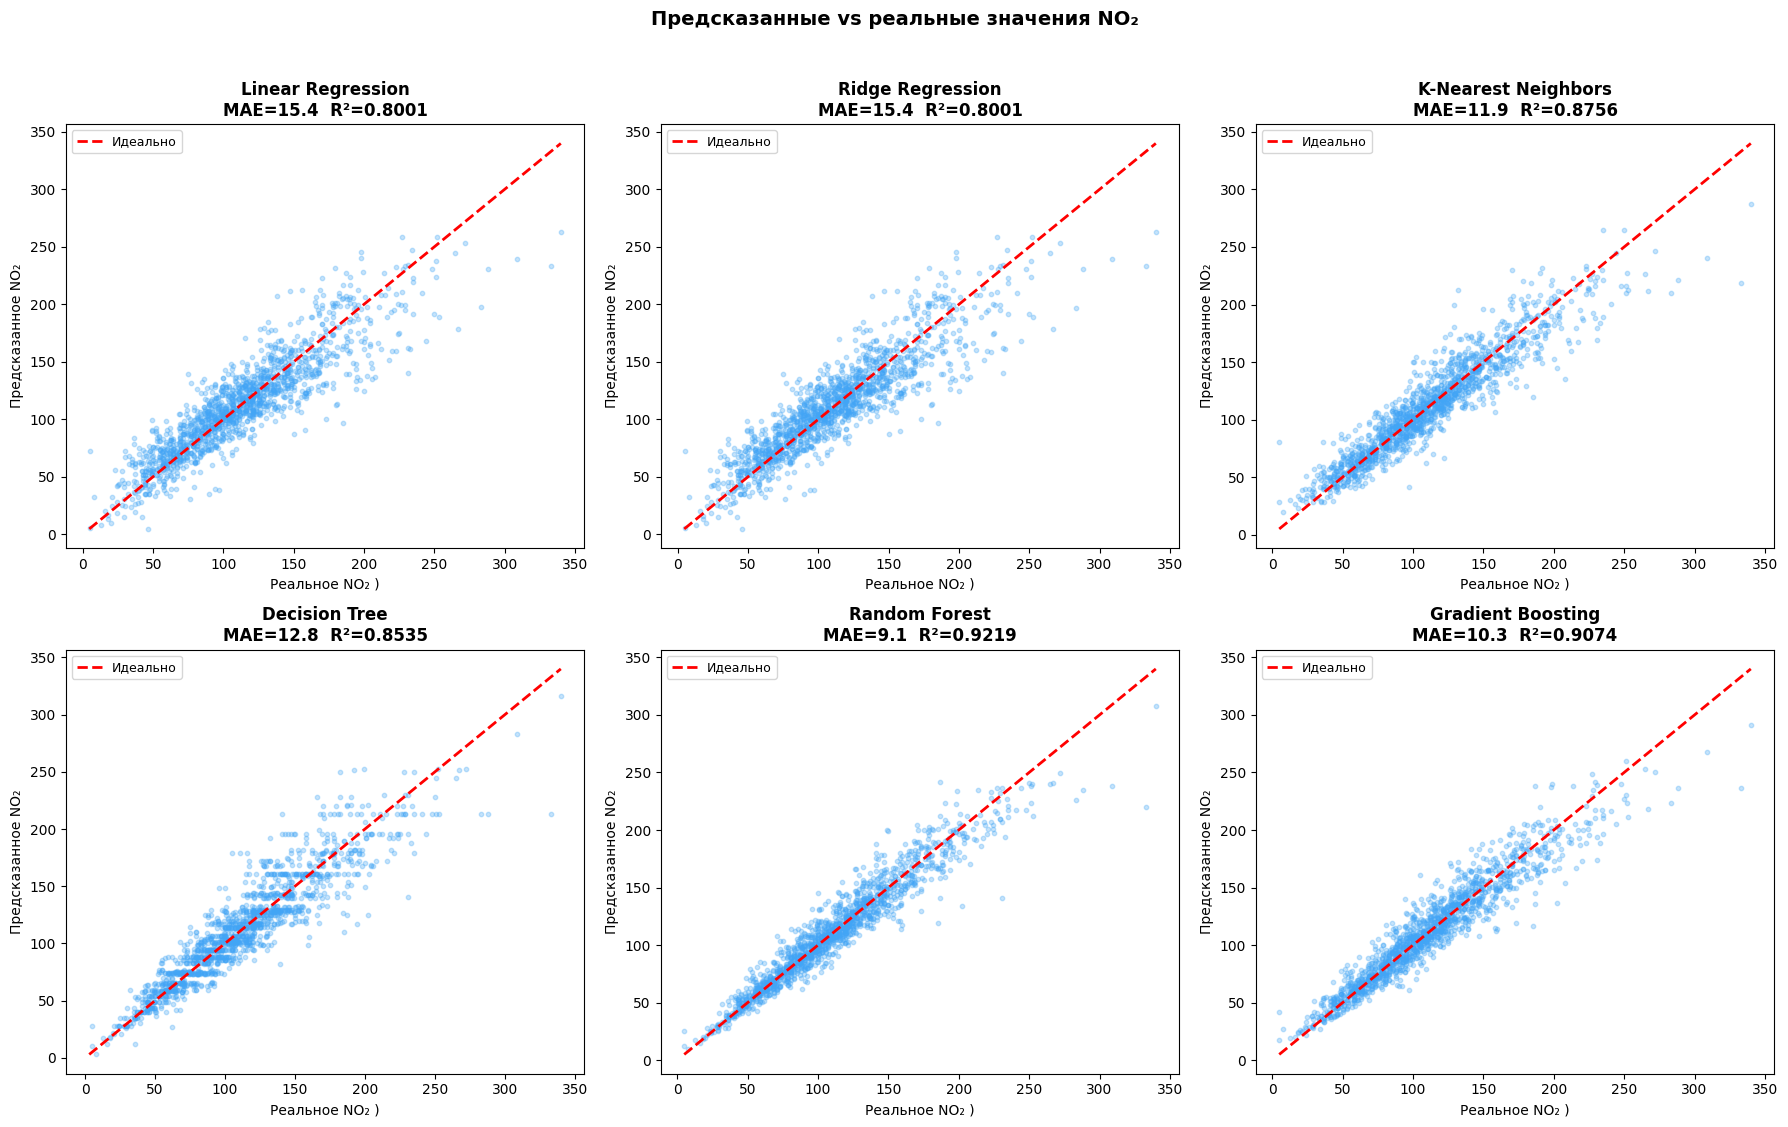

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    axes[i].scatter(y_test, res['y_pred'], alpha=0.3, s=10, color='#42A5F5')

    lims = [min(y_test.min(), res['y_pred'].min()), max(y_test.max(), res['y_pred'].max())]
    axes[i].plot(lims, lims, 'r--', lw=2, label='Идеально')
    axes[i].set_xlabel('Реальное NO₂ )')
    axes[i].set_ylabel('Предсказанное NO₂')
    axes[i].set_title(f'{name}\nMAE={res["mae"]:.1f}  R²={res["r2"]:.4f}', fontweight='bold')
    axes[i].legend(fontsize=9)

plt.suptitle('Предсказанные vs реальные значения NO₂', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


У Random Forest и GBM облако точек плотно прилегает к линии. У линейной регрессии заметен систематический разброс особенно на высоких значениях NO₂.

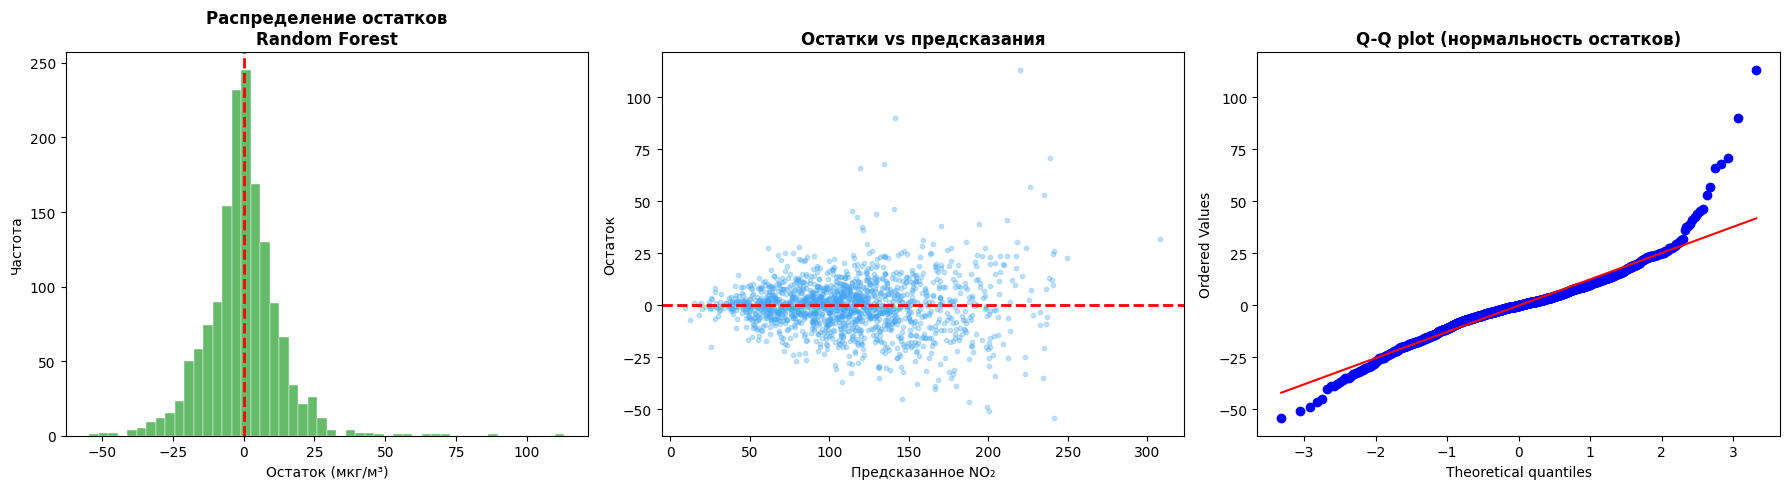

In [ ]:
best_name = max(results, key=lambda k: results[k]['r2'])
best = results[best_name]
residuals = y_test.values - best['y_pred']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(residuals, bins=50, color='#66BB6A', edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='red', lw=2, linestyle='--')
axes[0].set_title(f'Распределение остатков\n{best_name}', fontweight='bold')
axes[0].set_xlabel('Остаток (мкг/м³)'); axes[0].set_ylabel('Частота')

axes[1].scatter(best['y_pred'], residuals, alpha=0.3, s=10, color='#42A5F5')
axes[1].axhline(0, color='red', lw=2, linestyle='--')
axes[1].set_xlabel('Предсказанное NO₂'); axes[1].set_ylabel('Остаток')
axes[1].set_title('Остатки vs предсказания', fontweight='bold')

stats.probplot(residuals, plot=axes[2])
axes[2].set_title('Q-Q plot (нормальность остатков)', fontweight='bold')

plt.tight_layout()
plt.show()


Распределение остатков близко к нормальному и центрировано около нуля это хороший признак. Q-Q plot подтверждает нормальность. На графике «остатки vs предсказания» нет явного паттерна, что говорит об отсутствии систематической ошибки.

---
## 7. Настройка гиперпараметров

In [ ]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2', 0.5],
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print("Лучшие параметры RF:")
for k, v in rf_grid.best_params_.items():
    print(f"{k}: {v}")

print(f"CV RMSE до: {results['Random Forest']['cv_rmse']:.3f}")
print(f"CV RMSE после: {-rf_grid.best_score_:.3f}")


Лучшие параметры RF:
 max_depth: 20
 max_features: 0.5
 min_samples_split: 2
 n_estimators: 300
 CV RMSE до: 13.502
 CV RMSE после: 13.290


Перебор сетки параметров с кросс-валидацией. Улучшение по сравнению с дефолтными параметрами есть, но небольшое.

In [ ]:
from scipy.stats import randint, uniform

gbm_param_dist = {
    'n_estimators': randint(50, 300),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(2, 8),
    'min_samples_split': randint(2, 10),
    'subsample': uniform(0.7, 0.3),
}

gbm_random = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=SEED),
    param_distributions=gbm_param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=SEED,
    n_jobs=-1
)
gbm_random.fit(X_train, y_train)

print(f"\nЛучшие параметры GBM:")
for k, v in gbm_random.best_params_.items():
    print(f"{k}: {round(v,4) if isinstance(v,float) else v}")
print(f"CV RMSE до: {results['Gradient Boosting']['cv_rmse']:.3f}")
print(f"CV RMSE после: {-gbm_random.best_score_:.3f}")



Лучшие параметры GBM:
   learning_rate: 0.1034
   max_depth: 6
   min_samples_split: 4
   n_estimators: 184
   subsample: 0.7512
   CV RMSE до:    14.698
   CV RMSE после: 12.069


Для Gradient Boosting пространство параметров шире, поэтому случайный поиск эффективнее полного перебора. n_iter=30 - достаточное число итераций для нахождения хорошего решения без лишних вычислительных затрат.

                                    MAE    RMSE      R²
RF (исходный)                     9.092  13.055  0.9219
RF (после настройки параметрв)    8.932  12.805  0.9249
GBM (исходный)                   10.307  14.220  0.9074
GBM (после настройки параметрв)   8.295  11.622  0.9381


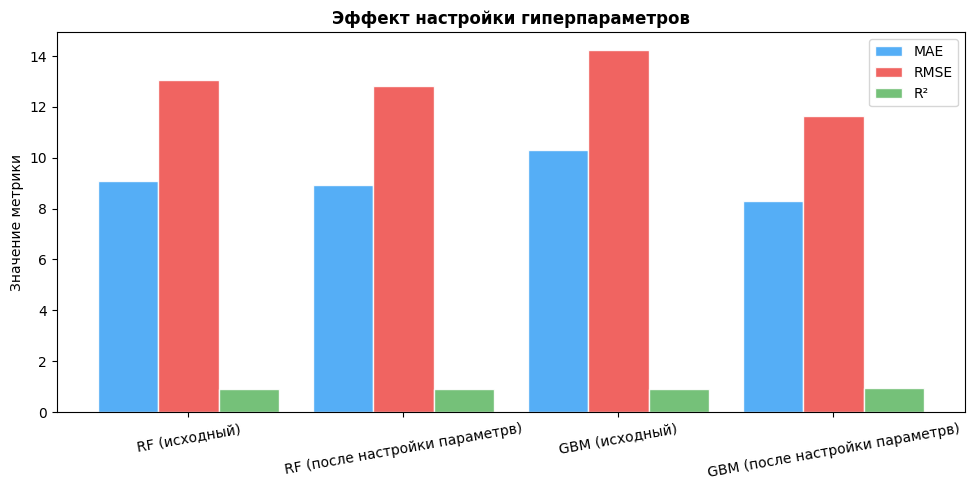

In [ ]:
tuned_models = {
    'RF (исходный)': results['Random Forest']['model'],
    'RF (после настройки параметрв)': rf_grid.best_estimator_,
    'GBM (исходный)': results['Gradient Boosting']['model'],
    'GBM (после настройки параметрв)': gbm_random.best_estimator_,
}

tuning_results = {}
for name, model in tuned_models.items():
    yp = model.predict(X_test)
    tuning_results[name] = {
        'MAE': round(mean_absolute_error(y_test, yp), 3),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, yp)), 3),
        'R²': round(r2_score(y_test, yp), 4),
    }

tuning_df = pd.DataFrame(tuning_results).T
print(tuning_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(tuning_df))
w = 0.28
for j, (met, col) in enumerate(zip(['MAE','RMSE','R²'], ['#42A5F5','#EF5350','#66BB6A'])):
    vals = tuning_df[met].values
    ax.bar(x + j*w, vals, w, label=met, color=col, edgecolor='white', alpha=0.9)

ax.set_xticks(x + w)
ax.set_xticklabels(tuning_df.index, rotation=10)
ax.set_ylabel('Значение метрики')
ax.set_title('Эффект настройки гиперпараметров', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


Настройка гиперпараметров дала умеренное улучшение для RF, но для GBM присутствуют заметные улучшения по RMSE.

---
## 8. Интерпретация модели и важность признаков

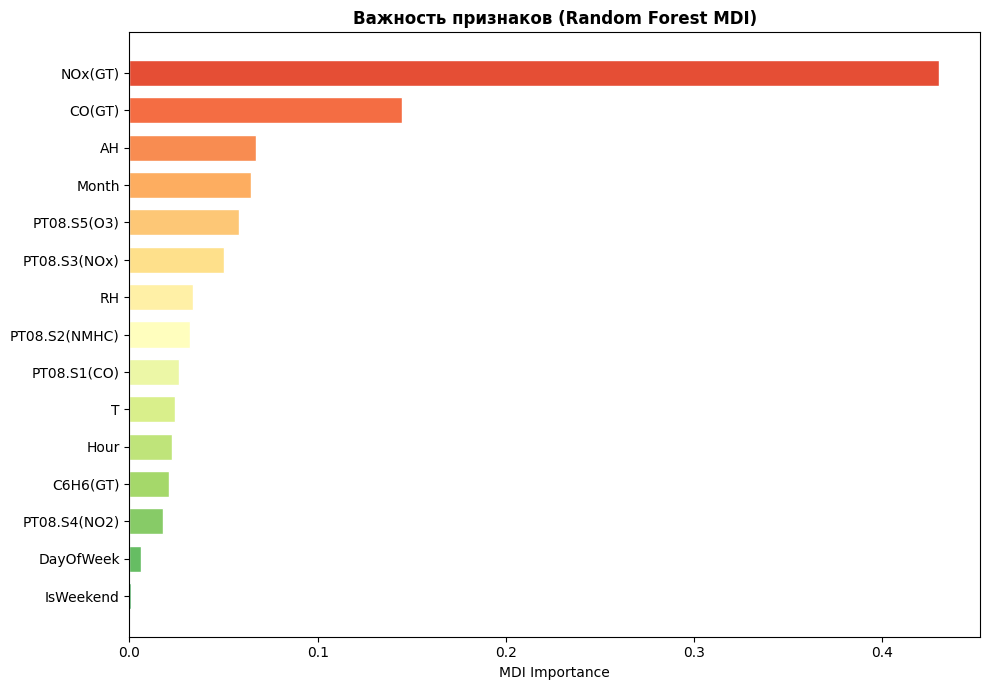

In [ ]:
best_rf = rf_grid.best_estimator_
importances = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(importances)))
ax.barh(importances.index[::-1], importances.values[::-1], color=colors, edgecolor='white', height=0.7)
ax.set_xlabel('MDI Importance')
ax.set_title('Важность признаков (Random Forest MDI)', fontweight='bold')
plt.tight_layout()
plt.show()

NOx-сенсор ожидаемо на первом месте химическая связь с NO₂ прямая. Температура и час суток также в топе, что подтверждает находки из EDA. Признаки выходного дня и месяца менее важны, но всё же вносят вклад.

In [ ]:
import shap

shap_explainer = shap.TreeExplainer(best_rf)

X_shap = X_test.iloc[:500]
shap_values = shap_explainer.shap_values(X_shap.values)
shap_arr = np.array(shap_values)

print(f"SHAP values shape: {shap_arr.shape}")

mean_shap = np.abs(shap_arr).mean(axis=0)
shap_global = pd.Series(mean_shap, index=X_test.columns).sort_values(ascending=False)

print("\nТоп-10 признаков по Mean:")
for feat, val in shap_global.head(10).items():
    print(f"{feat} {val}")


SHAP values shape: (500, 15)

Топ-10 признаков по Mean:
  NOx(GT)                21.2226
  CO(GT)                 6.9723
  Month                  5.9862
  AH                     4.9098
  RH                     3.6140
  Hour                   2.6067
  PT08.S5(O3)            2.2380
  PT08.S2(NMHC)          2.1915
  PT08.S3(NOx)           2.1733
  T                      1.8395


SHAP показывает, что высокие значения NOx толкают предсказание вверх, а высокая температура вниз.

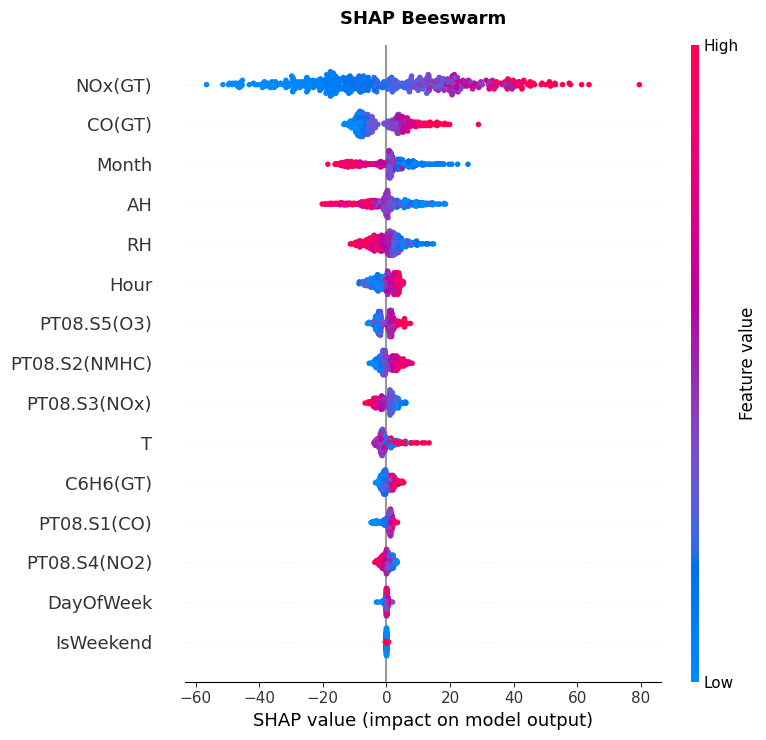

In [ ]:
shap.summary_plot(shap_arr, X_shap.values,
                  feature_names=X_test.columns.tolist(),
                  max_display=15,
                  show=False,
                  plot_type='dot')
plt.title('SHAP Beeswarm', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Каждая точка это одно наблюдение. Красный цвет означает высокое значение признака, синий низкое. Паттерны подтверждают физический смысл: больше NOx -> выше NO₂, выше температура -> ниже NO₂.

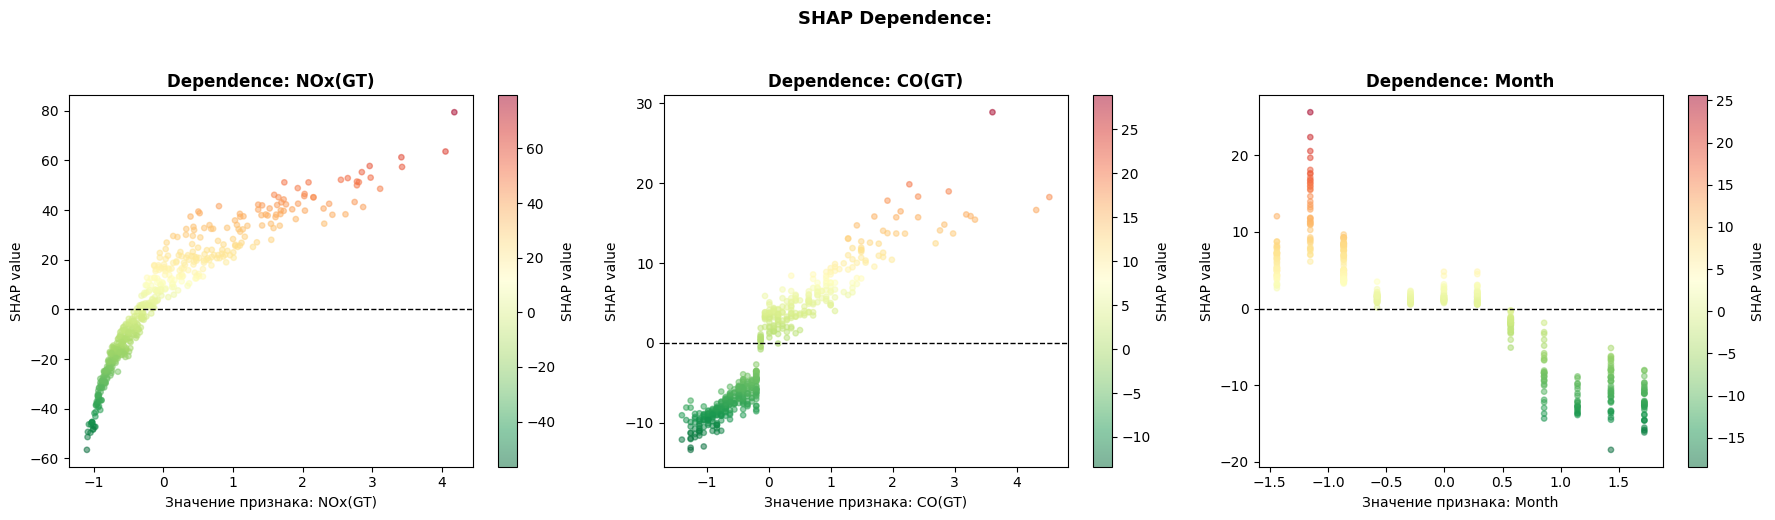

In [ ]:
top3 = shap_global.head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feat in enumerate(top3):
    feat_idx = list(X_test.columns).index(feat)
    sc = axes[i].scatter(
        X_shap.values[:, feat_idx],
        shap_arr[:, feat_idx],
        c=shap_arr[:, feat_idx],
        cmap='RdYlGn_r', alpha=0.5, s=15
    )
    plt.colorbar(sc, ax=axes[i], label='SHAP value')
    axes[i].axhline(0, color='black', lw=1, linestyle='--')
    axes[i].set_xlabel(f'Значение признака: {feat}')
    axes[i].set_ylabel('SHAP value')
    axes[i].set_title(f'Dependence: {feat}', fontweight='bold')

plt.suptitle('SHAP Dependence:', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


Графики показывают нелинейный характер зависимостей. У NOx зависимость почти линейная. У температуры виден более сложный эффект при очень низких температурах влияние особенно сильное.



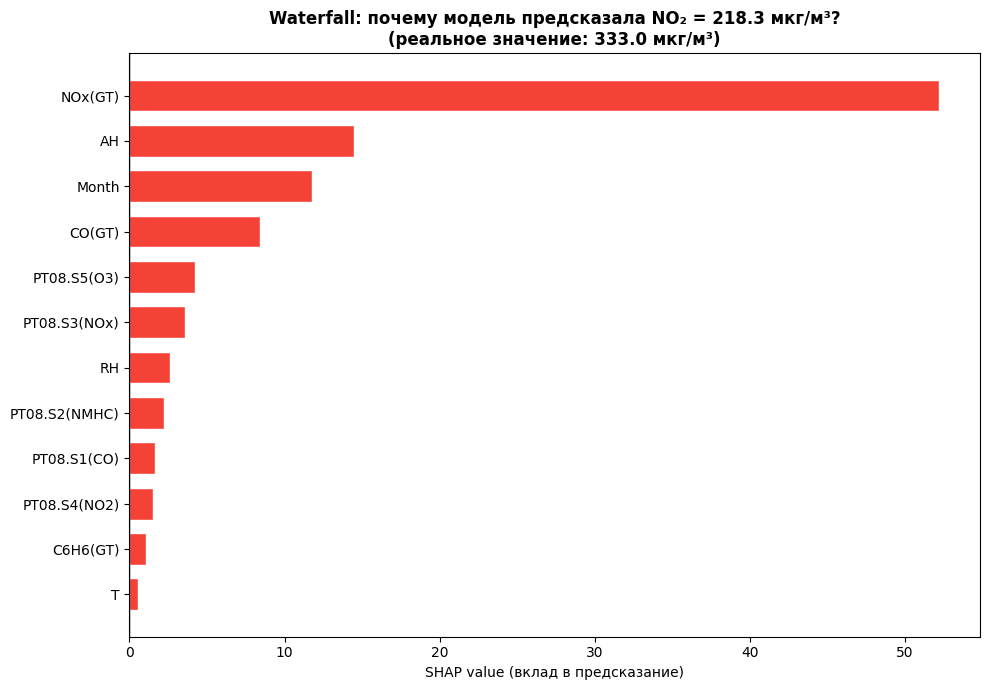

In [ ]:
high_no2_idx = np.argmax(y_test.values[:500])
sample_shap  = shap_arr[high_no2_idx]
sample_x = X_shap.values[high_no2_idx]
actual_no2 = y_test.values[high_no2_idx]
pred_no2 = best_rf.predict(X_shap.iloc[[high_no2_idx]])[0]

top_idx = np.argsort(np.abs(sample_shap))[-12:][::-1]
top_feats = [X_test.columns[i] for i in top_idx]
top_shap = sample_shap[top_idx]

fig, ax = plt.subplots(figsize=(10, 7))
colors_wf = ['#F44336' if v > 0 else '#4CAF50' for v in top_shap]
ax.barh(range(len(top_feats)), top_shap[::-1], color=colors_wf[::-1], edgecolor='white', height=0.7)
ax.set_yticks(range(len(top_feats)))
ax.set_yticklabels(top_feats[::-1])
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('SHAP value (вклад в предсказание)')
ax.set_title(f'Waterfall: почему модель предсказала NO₂ = {pred_no2:.1f} мкг/м³?\n' f'(реальное значение: {actual_no2:.1f} мкг/м³)', fontweight='bold')
plt.tight_layout()
plt.show()


Видно какие признаки и насколько сдвинули предсказание от базового значения вверх (красные) или вниз (зелёные). Это делает модель прозрачной и объяснимой. Зеленых баров нет, что говорит об тотальной доминации признаков, которые тянут значение вверх

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


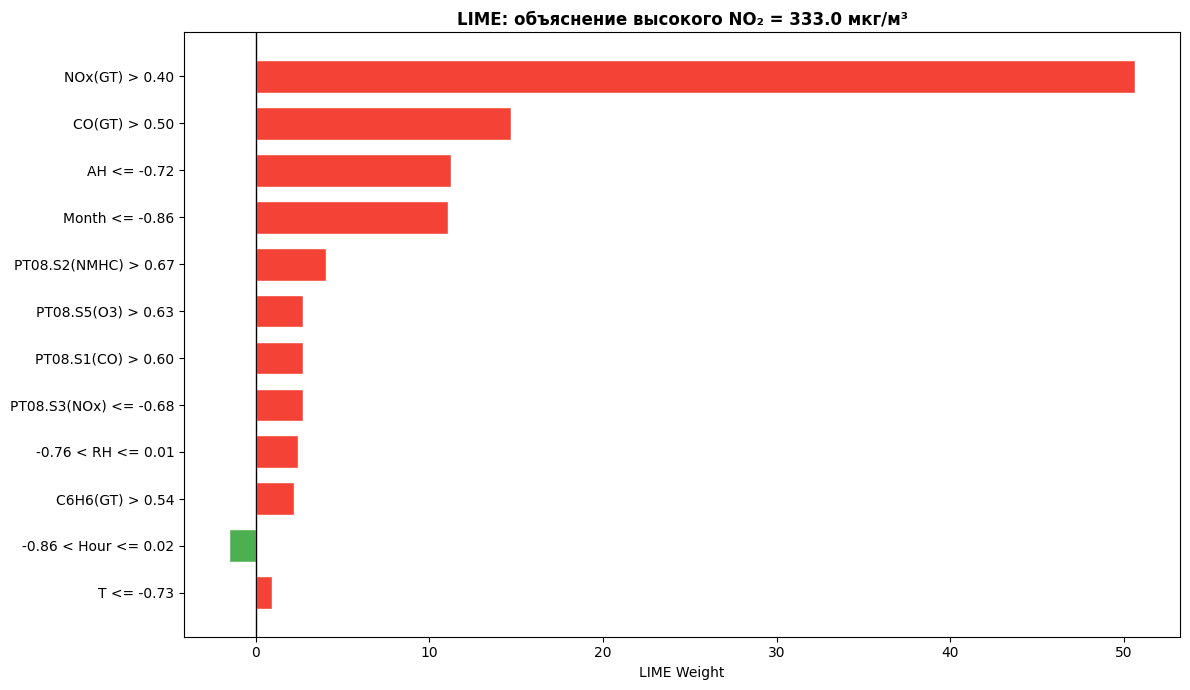

In [ ]:
import lime.lime_tabular

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    mode='regression',
    random_state=SEED
)

lime_exp = lime_explainer.explain_instance(
    data_row=X_shap.values[high_no2_idx],
    predict_fn=best_rf.predict,
    num_features=12
)

lime_list = lime_exp.as_list()
lime_df = pd.DataFrame(lime_list, columns=['Условие', 'Вес'])
lime_sorted = lime_df.reindex(lime_df['Вес'].abs().sort_values().index)

fig, ax = plt.subplots(figsize=(12, 7))
colors_l = ['#F44336' if w > 0 else '#4CAF50' for w in lime_sorted['Вес']]
ax.barh(lime_sorted['Условие'], lime_sorted['Вес'], color=colors_l, edgecolor='white', height=0.7)
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('LIME Weight')
ax.set_title(f'LIME: объяснение высокого NO₂ = {actual_no2:.1f} мкг/м³', fontweight='bold')
plt.tight_layout()
plt.show()


LIME строит локальную линейную аппроксимацию вокруг одного наблюдения. Результаты согласуются с SHAP и оба метода указывают на одни и те же ключевые признаки. Совпадение SHAP, LIME потверждает значимость признаков

---
## 9. Итоги и выводы

In [ ]:
for name, res in results.items():
    print(f"{name}: cv_rmse={res['cv_rmse']}, mae={res['mae']}, rmse={res['rmse']}, r2={res['r2']}")

print("\nПосле настройки:")
for name, res in tuning_results.items():
    print(f"{name}: MAE={res['MAE']}, RMSE={res['RMSE']}, R²={res['R²']}")


Linear Regression: cv_rmse=21.25468175532101, mae=15.407649136653902, rmse=20.88711971683712, r2=0.800122204714191
Ridge Regression: cv_rmse=21.254147093996174, mae=15.408019526003613, rmse=20.888179772659765, r2=0.8001019159429047
K-Nearest Neighbors: cv_rmse=16.776402430066486, mae=11.884732895102307, rmse=16.47684064757584, r2=0.87561863415091
Decision Tree: cv_rmse=18.491091878515395, mae=12.774377762555366, rmse=17.882584785255457, r2=0.8534897450468495
Random Forest: cv_rmse=13.502473143490572, mae=9.091941023979262, rmse=13.055171786905467, r2=0.9219141000006376
Gradient Boosting: cv_rmse=14.698194300641756, mae=10.307328811612543, rmse=14.219716026135393, r2=0.9073619754632927

После настройки:
RF (исходный): MAE=9.092, RMSE=13.055, R²=0.9219
RF (после настройки параметрв): MAE=8.932, RMSE=12.805, R²=0.9249
GBM (исходный): MAE=10.307, RMSE=14.22, R²=0.9074
GBM (после настройки параметрв): MAE=8.295, RMSE=11.622, R²=0.9381


**Итоги проекта.** В ходе работы было протестировано шесть моделей машинного обучения для предсказания концентрации NO₂ по данным сенсоров. Лучший результат показал GMB после настройки гиперпараметров. Линейные модели были не настолько точны как ансамблевые, что подтверждает нелинейный характер зависимостей в данных.

SHAP показал, что концентрацию NO₂ сильнее всего объясняют показания NOx-сенсора и температура, так как NO₂ является продуктом окисления NO, а температура влияет на скорость реакций и рассеивание загрязнителей.

EDA показал, что загрязнение происходит по определенным временным промежуткам с пиками в утренние и вечерние часы, это соответствует часу пик на дорогах. При этом большинство измерений превышает норму ВОЗ (40 мкг/м³), поэтому проблема является достаточно значительнй